In [ ]:
!pip install nilearn pandas scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 83.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [ ]:
adhd = datasets.fetch_adhd(n_subjects=30)
print("Scans:", len(adhd.func))

[fetch_adhd] Added README.md to /root/nilearn_data

[fetch_adhd] Dataset created in /root/nilearn_data/adhd

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7781/adhd40_metadata.tgz ...

[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /root/nilearn_data/adhd/fbef5baff0b388a8c913a08e1d84e059/adhd40_metadata.tgz...

...

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7811/adhd40_4016887.tgz ...

[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /root/nilearn_data/adhd/1195d4b51afa739d0af4c7d508e1f39a/adhd40_4016887.tgz...

[fetch_adhd] .. done.

Scans: 30


In [ ]:
atlas = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

In [ ]:
labels = adhd.phenotypic["adhd"].values

correlation_measure = ConnectivityMeasure(
    kind="correlation",
    standardize="zscore_sample"
)

X = []
y = []

for func_file, label in zip(adhd.func, labels):
    ts = masker.fit_transform(func_file)
    conn = correlation_measure.fit_transform([ts])[0]
    feat = conn[np.triu_indices_from(conn, k=1)]

    X.append(feat)
    y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(20, 1128) (20,)


In [ ]:
clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_pred = cross_val_predict(clf, X, y, cv=cv)
y_prob = cross_val_predict(
    clf, X, y, cv=cv, method="predict_proba"
)[:, 1]

In [ ]:
acc = accuracy_score(y, y_pred)
auc = roc_auc_score(y, y_prob)

print(f"Accuracy: {acc:.2f}")
print(f"ROC-AUC : {auc:.2f}")
print()
print(classification_report(y, y_pred))

Accuracy: 0.20
ROC-AUC : 0.04

              precision    recall  f1-score   support

           0       0.12      0.10      0.11        10
           1       0.25      0.30      0.27        10

    accuracy                           0.20        20
   macro avg       0.19      0.20      0.19        20
weighted avg       0.19      0.20      0.19        20



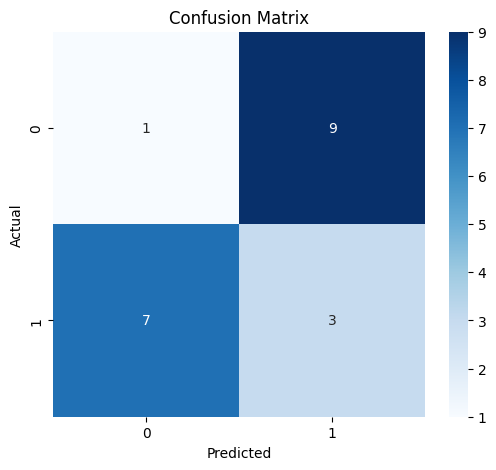

In [ ]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

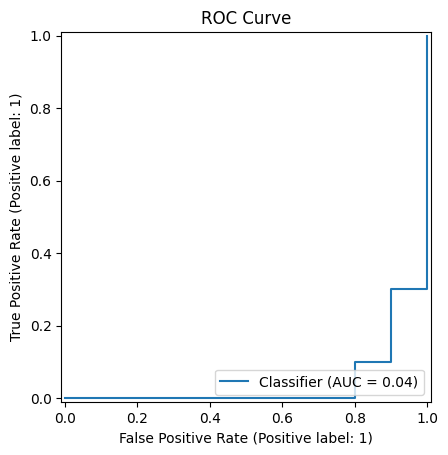

In [ ]:
RocCurveDisplay.from_predictions(y, y_prob)
plt.title("ROC Curve")
plt.show()